In [397]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import plotly.express as px
from matplotlib.colors import ListedColormap
from scipy.stats import norm, skew
from sklearn import preprocessing
import statsmodels.api as sm

In [354]:
# 1. Carga los datos y explóralos. Elimina los datos nulos o incorrectos
df = pd.read_csv("cardio.csv")
df.shape

(4238, 16)

In [355]:
df.head()

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,M,39,4.0,No,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,F,46,2.0,No,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,M,48,1.0,Yes,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,F,61,3.0,Yes,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,F,46,3.0,Yes,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [356]:
# nulos
df.apply(lambda x: x.isnull().sum()).sort_values(ascending=False)

glucose            388
education          105
BPMeds              53
totChol             50
cigsPerDay          29
BMI                 19
heartRate            1
sex                  0
age                  0
currentSmoker        0
prevalentStroke      0
prevalentHyp         0
diabetes             0
sysBP                0
diaBP                0
TenYearCHD           0
dtype: int64

In [357]:
df.dtypes

sex                 object
age                  int64
education          float64
currentSmoker       object
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [358]:
df1 = df[['glucose','education','BPMeds','totChol','cigsPerDay','BMI','heartRate']]
df1.tail()

,glucose,education,BPMeds,totChol,cigsPerDay,BMI,heartRate
4233,86.0,1.0,0.0,313.0,1.0,25.97,66.0
4234,68.0,3.0,0.0,207.0,43.0,19.71,65.0
4235,86.0,2.0,NaN,248.0,20.0,22.00,84.0
4236,NaN,1.0,0.0,210.0,15.0,19.16,86.0
4237,107.0,2.0,0.0,269.0,0.0,21.47,80.0


In [359]:
# reemplazamos nulos por sus promedios
columna = list(df1.columns)

for item in columna:
    promedio = round(df1[item].mean(),2)
    df1[item] = df1[item].fillna(promedio)
    df1[item].isnull().sum()
df1.tail()

C:\Users\User\AppData\Local\Temp\ipykernel_16236\1878675677.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[item] = df1[item].fillna(promedio)


,glucose,education,BPMeds,totChol,cigsPerDay,BMI,heartRate
4233,86.00,1.0,0.00,313.0,1.0,25.97,66.0
4234,68.00,3.0,0.00,207.0,43.0,19.71,65.0
4235,86.00,2.0,0.03,248.0,20.0,22.00,84.0
4236,81.97,1.0,0.00,210.0,15.0,19.16,86.0
4237,107.00,2.0,0.00,269.0,0.0,21.47,80.0


In [360]:
# duplicados
df1.duplicated().sum()
"...sin duplicados"

'...sin duplicados'

In [364]:
# unificamos la tabla con las columnas modificadas sin nulos

df1= pd.concat([df1[['glucose','education','BPMeds','totChol','cigsPerDay','BMI','heartRate']], df[['sex','age','currentSmoker','prevalentStroke','prevalentHyp','diabetes','sysBP','diaBP','TenYearCHD']]],axis=1)
df1.tail()

,glucose,education,BPMeds,totChol,cigsPerDay,BMI,heartRate,sex,age,currentSmoker,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,TenYearCHD
4233,86.00,1.0,0.00,313.0,1.0,25.97,66.0,M,50,Yes,0,1,0,179.0,92.0,1
4234,68.00,3.0,0.00,207.0,43.0,19.71,65.0,M,51,Yes,0,0,0,126.5,80.0,0
4235,86.00,2.0,0.03,248.0,20.0,22.00,84.0,F,48,Yes,0,0,0,131.0,72.0,0
4236,81.97,1.0,0.00,210.0,15.0,19.16,86.0,F,44,Yes,0,0,0,126.5,87.0,0
4237,107.00,2.0,0.00,269.0,0.0,21.47,80.0,F,52,No,0,0,0,133.5,83.0,0


Text(0.5, 1.0, 'Matriz de Correlacion')

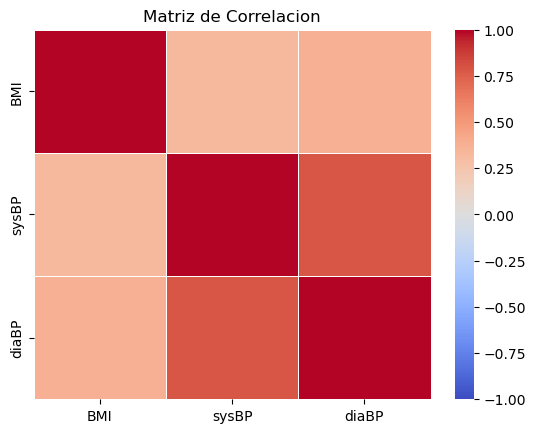

In [365]:
# 2. Escoge tres variables cuantitativas y realiza un análisis descriptivo de ellas,
# utilizando indicadores y gráficos. ¿Cuaĺ presenta mayor dispersión?

df2 = df1[['BMI','sysBP','diaBP']]
df2

corr = df2[df2.columns].corr()
corr

sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlacion')

In [366]:
df2.corr()

,BMI,sysBP,diaBP
BMI,1.000000,0.325247,0.376545
sysBP,0.325247,1.000000,0.784002
diaBP,0.376545,0.784002,1.000000


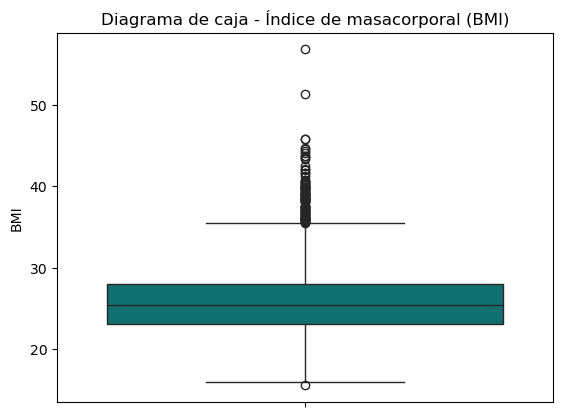

In [367]:
sns.boxplot(y='BMI',data=df2, color='teal')

plt.title('Diagrama de caja - Índice de masacorporal (BMI)')
plt.show()

In [368]:
array = df2['BMI']

media = np.mean(array)
desviacion =np.std(array)
lic = media - (3*desviacion)
lsc = media + (3*desviacion)
condicion1 = array< lic
condicion2 = array>lsc
valores_fuera = array[np.logical_or(condicion1, condicion2)]
#fuera_de_control = quality_column[np.logical_or(quality_column < lic, quality_column > lsc)]

print(f'la media es: {media}')
print(f'desviacion es: {desviacion}')
print(f'el límite inferior de control (LIC): {lic}')
print(f'límite superior de control (LSC): {lsc}')
print('Valores fuera de control: ',valores_fuera.size)
print(valores_fuera if valores_fuera.size > 0 else "No se encontraron valores fuera de control.")

la media es: 25.801998584237847
desviacion es: 4.070472234564726
el límite inferior de control (LIC): 13.590581880543667
límite superior de control (LSC): 38.01341528793203
Valores fuera de control:  60
35      38.53
37      40.11
78      45.80
87      38.46
108     40.52
114     42.15
143     38.39
165     42.00
249     44.27
264     38.14
409     39.88
433     45.79
481     38.82
675     39.60
750     44.09
829     40.58
833     43.30
894     43.69
969     42.53
1183    38.88
1286    38.38
1520    38.75
1525    44.55
1715    39.64
1853    38.06
1985    39.91
2019    38.43
2162    44.71
2167    38.54
2170    39.04
2180    38.42
2245    39.53
2262    39.54
2307    43.48
2373    39.08
2388    39.69
2492    39.82
2657    56.80
2668    38.11
2697    40.21
2883    39.40
2907    40.81
2930    38.61
2986    39.21
3094    40.51
3366    38.31
3522    38.96
3581    39.94
3648    39.94
3657    39.22
3659    41.29
3678    40.08
3738    41.61
3899    40.38
3927    51.28
3952    38.94
4001    41.66

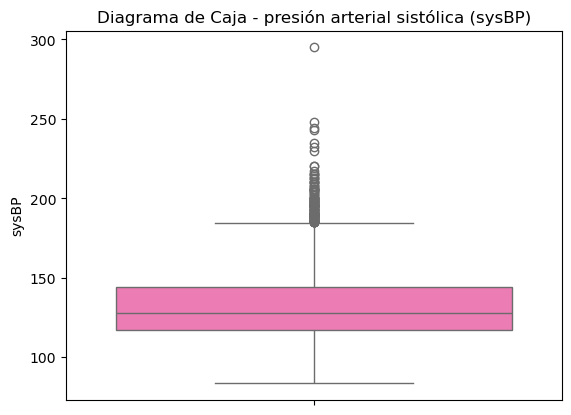

In [369]:
sns.boxplot(y='sysBP',data=df2, color= 'hotpink')
plt.title('Diagrama de Caja - presión arterial sistólica (sysBP)')
plt.show()

In [370]:
array = df2['sysBP']

media2 = np.mean(array)
desviacion2 =np.std(array)
lic = media2 - (3*desviacion2)
lsc = media2 + (3*desviacion2)
condicion1 = array< lic
condicion2 = array>lsc
valores_fuera2 = array[np.logical_or(condicion1,condicion2)]
#fuera_de_control = quality_column[np.logical_or(quality_column < lic, quality_column > lsc)]

print(f'la media es: {media2}')
print(f'desviacion es: {desviacion2}')
print(f'el límite inferior de control (LIC): {lic}')
print(f'límite superior de control (LSC): {lsc}')
print('Valores fuera de control:', valores_fuera2.size)
print(valores_fuera2 if valores_fuera2.size > 0 else "No se encontraron valores fuera de control.")

la media es: 132.35240679565834
desviacion es: 22.035496431554705
el límite inferior de control (LIC): 66.24591750099422
límite superior de control (LSC): 198.45889609032247
Valores fuera de control: 48
44      206.0
87      200.0
153     212.0
249     200.0
333     204.0
369     215.0
446     209.0
481     295.0
590     220.0
664     205.5
833     200.0
864     244.0
903     213.0
924     206.0
932     199.0
1003    206.0
1079    201.0
1189    243.0
1520    199.0
1567    204.0
1588    217.0
1751    202.0
1878    200.0
1989    232.0
2091    235.0
2132    205.0
2162    220.0
2179    210.0
2304    199.0
2416    210.0
2459    202.5
2608    208.0
2645    205.0
2683    210.0
2909    204.0
2930    207.5
3062    215.0
3214    199.5
3489    248.0
3554    202.0
3616    230.0
3675    214.0
3844    215.0
3981    207.0
4040    213.0
4076    200.0
4123    206.0
4173    210.0
Name: sysBP, dtype: float64


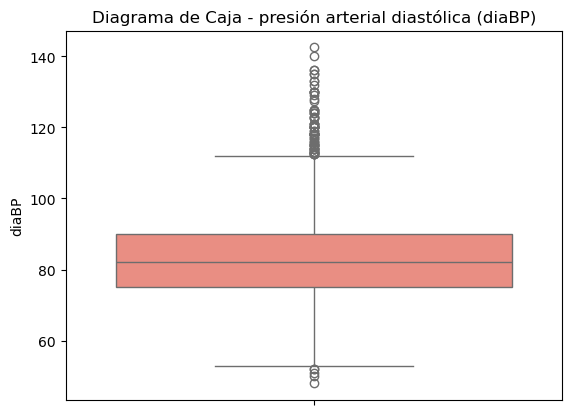

In [371]:
sns.boxplot(y='diaBP',data=df2, color='salmon')
plt.title('Diagrama de Caja - presión arterial diastólica (diaBP)')
plt.show()

In [372]:
array = df2['diaBP']

media3 = np.mean(array)
desviacion3 =np.std(array)
lic = media3 - (3*desviacion3)
lsc = media3 + (3*desviacion3)
condicion1 = array< lic
condicion2 = array>lsc
valores_fuera3 = array[np.logical_or(condicion1,condicion2)]
#fuera_de_control = quality_column[np.logical_or(quality_column < lic, quality_column > lsc)]

print(f'la media es: {media3}')
print(f'desviacion es: {desviacion3}')
print(f'el límite inferior de control (LIC): {lic}')
print(f'límite superior de control (LSC): {lsc}')
print('Valores fuera de control:', valores_fuera3.size)
print(valores_fuera3 if valores_fuera3.size > 0 else "No se encontraron valores fuera de control.")

la media es: 82.89346389806512
desviacion es: 11.909444273148404
el límite inferior de control (LIC): 47.16513107861991
límite superior de control (LSC): 118.62179671751034
Valores fuera de control: 41
28      121.0
158     124.5
249     122.5
407     123.0
409     120.0
423     120.0
446     133.0
481     135.0
531     121.0
833     140.0
864     124.0
1189    142.5
1608    120.0
1614    119.0
1751    132.0
1760    124.0
1808    123.0
1878    120.0
1989    136.0
2088    120.0
2093    128.0
2179    120.0
2307    125.0
2416    130.0
2608    136.0
2657    130.0
2683    135.0
2872    121.0
3062    129.0
3322    120.0
3489    130.0
3532    119.0
3554    124.0
3635    121.0
3953    130.0
3981    122.5
4040    133.0
4075    125.0
4076    125.0
4173    127.5
4228    130.0
Name: diaBP, dtype: float64


In [373]:
"""
¿Cual tiene mayor dispersion?
Para comparar dispersiones entre las variables BMI, sysBP y diaBP utilizamos el coeficiente de variacion (CV):
CV = (desviacion Estandar / Media) * 100%
"""
# BMI
CV1 = (desviacion / media)*100
CV1 = round(CV1,2)

# sysBP
CV2 = (desviacion2 / media2)*100
CV2 = round(CV2,2)

# diaBP
CV3 = (desviacion3 / media3)*100
CV3 = round(CV3,2)

print('El coeficiente de variacion del Índice de masacorporal (BMI) es',CV1)
print('El coeficiente de variacion de la presión arterial sistólica (sysBP) es',CV2)
print('El coeficiente de variacion de la presión arterial diastólica (diaBP) es',CV3)

El coeficiente de variacion del Índice de masacorporal (BMI) es 15.78
El coeficiente de variacion de la presión arterial sistólica (sysBP) es 16.65
El coeficiente de variacion de la presión arterial diastólica (diaBP) es 14.37


In [374]:
"""
Podemos observar que la segunda variable, la presion arterial sistolica (sysBP), presenta mayor dispersion de datos 
que las demas seleccionadas. Ahora veamos que el mapa de calor nos muestra que la correlacion entre sysBP y diaBP 
es fuerte con 78.40% mientras que la relacion es moderada fuerte entre BMI y diaBP con 37.65%, y moderada debil 
entre BMI y sysBP con 32.52%. Finalmente podemos deducir que ante un aumento de la presion arterial sistolica tambien 
aumentará la presion arterial diastolica, como tambien sucede ante un aumento del indice de masa corporal tambien 
aumentara la presion arterial diastolica, aunque con menor presicion debido a la dispersion de sus datos.
"""

'\nPodemos observar que la segunda variable, la presion arterial sistolica (sysBP), presenta mayor dispersion de datos \nque las demas seleccionadas. Ahora veamos que el mapa de calor nos muestra que la correlacion entre sysBP y diaBP \nes fuerte con 78.40% mientras que la relacion es moderada fuerte entre BMI y diaBP con 37.65%, y moderada debil \nentre BMI y sysBP con 32.52%. Finalmente podemos deducir que ante un aumento de la presion arterial sistolica tambien \naumentará la presion arterial diastolica, como tambien sucede ante un aumento del indice de masa corporal tambien \naumentara la presion arterial diastolica, aunque con menor presicion debido a la dispersion de sus datos.\n'

In [375]:
# 3. Elimina los datos atípicos del dataset. Para las siguientes preguntas, considera el
# dataset "limpio"
valores_fuera = list(valores_fuera.index)
valores_fuera2 = list(valores_fuera2.index)
valores_fuera3 = list(valores_fuera3.index)

lista_delete = list(set(valores_fuera + valores_fuera2 + valores_fuera3))
lista_delete.sort()

# eliminamos datos atipicos de df1
limpio = df1.drop(lista_delete)
limpio.shape

(4120, 16)

In [376]:
limpio.tail()

,glucose,education,BPMeds,totChol,cigsPerDay,BMI,heartRate,sex,age,currentSmoker,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,TenYearCHD
4233,86.00,1.0,0.00,313.0,1.0,25.97,66.0,M,50,Yes,0,1,0,179.0,92.0,1
4234,68.00,3.0,0.00,207.0,43.0,19.71,65.0,M,51,Yes,0,0,0,126.5,80.0,0
4235,86.00,2.0,0.03,248.0,20.0,22.00,84.0,F,48,Yes,0,0,0,131.0,72.0,0
4236,81.97,1.0,0.00,210.0,15.0,19.16,86.0,F,44,Yes,0,0,0,126.5,87.0,0
4237,107.00,2.0,0.00,269.0,0.0,21.47,80.0,F,52,No,0,0,0,133.5,83.0,0


Text(0.5, 1.0, 'Matriz de Correlacion de variables cuantitativas')

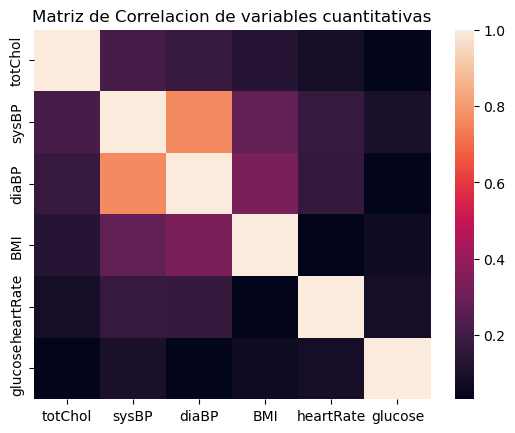

In [377]:
# 4. ¿Qué variables cuantitativas presentan mayor correlación? Explica.
cuantitativo = limpio[['totChol','sysBP','diaBP','BMI','heartRate','glucose']]
cuantitativo.corr()
sns.heatmap(cuantitativo.corr())
plt.title('Matriz de Correlacion de variables cuantitativas')

In [378]:
"""
diaBP y sysBP presentan una correlacion fuerte con 76.25%
BMI y diaBP presentan una correlacion moderada con 33.60%
BMI y sysBP presentan una correlacion moderada debil con 27.74%
"""
cuantitativo.corr()

,totChol,sysBP,diaBP,BMI,heartRate,glucose
totChol,1.000000,0.213726,0.173658,0.127822,0.087934,0.032155
sysBP,0.213726,1.000000,0.762499,0.277382,0.169364,0.099170
diaBP,0.173658,0.762499,1.000000,0.336032,0.168044,0.033343
BMI,0.127822,0.277382,0.336032,1.000000,0.035424,0.068667
heartRate,0.087934,0.169364,0.168044,0.035424,1.000000,0.086269
glucose,0.032155,0.099170,0.033343,0.068667,0.086269,1.000000


In [379]:
# 5. Si de este dataset se escoge un paciente al azar, ¿cuál es la probabilidad de que 
# sea hombre, si se sabe que pertenece al mayor cuartil de la variable correspondiente
# al índice de masa corporal?

# probabilidad de que sea hombre
conteo_hombre = (limpio['sex']=='M').sum()
conteo_mujer = (limpio['sex']=='F').sum()
total = conteo_hombre + conteo_mujer
p_hombre = conteo_hombre / total

# probabilidad de que pertenezca al cuartil 3 de BMI
    # Calculamos el cuartil 3 (75%) de la columna Indice de masa corporal (BMI)
Q3 = limpio['BMI'].quantile(0.75)

conteo_cuartil4 = (limpio['BMI'] > Q3).sum()
p_cuartil4 = conteo_cuartil4/len(limpio['BMI'])

hombre_y_cuartil4 = (conteo_hombre & conteo_cuartil4).sum()/total
hombre_dado_cuartil4 = hombre_y_cuartil4/p_cuartil4
print(f'la probabilidad de que eso ocurra es {round(hombre_dado_cuartil4,4)}')

la probabilidad de que eso ocurra es 0.9971


In [380]:
# 6. ¿Es razonable afirmar que, para una persona cualquiera (no necesariamente dentro
# del dataset), su ritmo cardiaco promedio es 75? Explica y justifica.

"""
H0: μ = 75
h1: μ ≠ 75 <- prueba de hipotesis bilateral 
"""
media = round(limpio['heartRate'].mean(),2)
t_stat, p_value = stats.ttest_1samp(limpio['heartRate'], media-75)
print(f"Valor t: {t_stat}")
print(f"Valor p: {p_value}\n")

print(f'con nivel de confianza del 95%, se rechaza la hipótesis nula ya que p_value={p_value} es menor que 0.05 se concluye que no es razonable afirmar que, para una persona cualquiera, su ritmo cardiaco promedio es 75.')

Valor t: 403.51643358780086
Valor p: 0.0

con nivel de confianza del 95%, se rechaza la hipótesis nula ya que p_value=0.0 es menor que 0.05 se concluye que no es razonable afirmar que, para una persona cualquiera, su ritmo cardiaco promedio es 75.


In [391]:
# 7. Ser hombre, ¿influye en el promedio de cigarrillos consumidos por día, dentro de 
# los pacientes fumadores? Explica.

"""
Prueba de independencia
H0: El sexo y el promedio de cigarrollos consumidos por dia (cigsPerDay) son independientes.
H1: El sexo y el promedio de cigarrollos consumidos por dia (cigsPerDay) no son independientes.
"""
import statsmodels.formula.api as smf
# 0. Filtro los pacientes fumadores en una nueva tabla
df_fumadores = limpio[limpio['currentSmoker']=='Yes']

# 1. Separar consumo diario de cigarrillos por sexo
hombres = df_fumadores[df_fumadores["sex"] == 'M']["cigsPerDay"].dropna()
mujeres = df_fumadores[df_fumadores["sex"] == 'F']["cigsPerDay"].dropna()

# 2. Prueba t de Student (asumo muestras independientes)
t_stat, p_val = stats.ttest_ind(hombres, mujeres, equal_var=False)

# 3. Regresión lineal para medir la magnitud del impacto
modelo = smf.ols("cigsPerDay ~ sex", data=df_fumadores).fit()

# Resultados
print(f"Cigarrillos Promedio Hombres: {hombres.mean():,.2f}")
print(f"Cigarrillos Promedio Mujeres: {mujeres.mean():,.2f}")
print(f"Diferencia observada:    {(hombres.mean() - mujeres.mean()):,.2f}\n")
print(f"Estadístico t: {t_stat:.4f}")
print(f"p-valor:       {p_val:.4e}")

print("\n--- RESUMEN DEL MODELO DE REGRESIÓN ---")
print(modelo.summary().tables[1])

Cigarrillos Promedio Hombres: 22.00
Cigarrillos Promedio Mujeres: 14.04
Diferencia observada:    7.96

Estadístico t: 18.1146
p-valor:       4.0626e-68

--- RESUMEN DEL MODELO DE REGRESIÓN ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.0435      0.325     43.264      0.000      13.407      14.680
sex[T.M]       7.9556      0.445     17.865      0.000       7.082       8.829


In [ ]:
"""
Con un nivel de significancia del 0.05 y un p-valor = 4.0626e-68, luego p-valor<0.05 entonces se rechaza la hipotesis nula.
Con respecto al modelo de regresion, con un 95% de certeza, la diferencia de consumo diario de cigarrillos mayor en hombres
se ubica entre 13 y 8 cigarrillos.

Asi que, existe evidencia estadistica para afirmar que el sexo si influye significativamente en el promedio de cigarrollos 
consumidos por dia observandose una diferencia donde hombres tienden a consumir en promedio 1.5 más veces que las mujeres.
"""

In [393]:
limpio[['glucose','education','totChol','cigsPerDay','heartRate','diabetes']]

,glucose,education,totChol,cigsPerDay,heartRate,diabetes
0,77.00,4.0,195.0,0.0,80.0,0
1,76.00,2.0,250.0,0.0,95.0,0
2,70.00,1.0,245.0,20.0,75.0,0
3,103.00,3.0,225.0,30.0,65.0,0
4,85.00,3.0,285.0,23.0,85.0,0
...,...,...,...,...,...,...
4233,86.00,1.0,313.0,1.0,66.0,0
4234,68.00,3.0,207.0,43.0,65.0,0
4235,86.00,2.0,248.0,20.0,84.0,0
4236,81.97,1.0,210.0,15.0,86.0,0


In [398]:
# 8. Construye un modelo de regresión lineal que permita relacionar 6 variables del
# dataset con el índice de masa corporal. (Debes incluir al menos dos variables
# cualitativas). Evalúa tu modelo y explica.

# Paso 1: Definir variables predictoras (X) y variable de respuesta (y)
X = limpio[['glucose','totChol','cigsPerDay','heartRate','education','sex']]
y = limpio['BMI']

# Codificar la variable categórica 'sex' usando get dummies
X_encoded = pd.get_dummies(X, columns=['sex','education'], drop_first=True, dtype=int)

# Paso 2: Agregar una constante (intercepto) a las variables predictoras
X_encoded = sm.add_constant(X_encoded)

# Paso 3: Crear el modelo de regresión lineal
model = sm.OLS(y, X_encoded).fit()

# Paso 4: Obtener resultados del modelo
results = model.summary()

predictions = model.predict(X_encoded)

# Calcular el Error Cuadrático Medio (MSE)
mse = ((y - predictions) ** 2).mean()

# Calcular el Error Cuadrático Medio Explicado (EMSE)
emse = mse / ((y - y.mean()) ** 2).mean()

# Obtener el valor R² del modelo
r2 = model.rsquared

print(results)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Error Mean Squared Explicado (EMSE): {emse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     38.05
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           1.61e-65
Time:                        00:28:03   Log-Likelihood:                -10992.
No. Observations:                4120   AIC:                         2.200e+04
Df Residuals:                    4110   BIC:                         2.207e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             21.6028      0.488     44.

In [ ]:
"""
Aunque la mayoría de las variables biológicas y demográficas resultaron ser estadísticamente significativas, 
el bajo valor de $R^2$ ($7.7\%$) demuestra que variables como la glucosa, el colesterol, el hábito de fumar
y el sexo no son suficientes por sí solas para predecir con precisión el BMI de una persona, recomendándose 
incorporar factores de estilo de vida en análisis futuros.
"""

In [410]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

=== VERIFICACIÓN DEL BALANCEO DE DATOS ===
            Cantidad  Porcentaje (%)
TenYearCHD                          
0               3523           85.51
1                597           14.49

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       0.93      0.68      0.78       881
           1       0.26      0.68      0.38       149

    accuracy                           0.68      1030
   macro avg       0.60      0.68      0.58      1030
weighted avg       0.83      0.68      0.72      1030



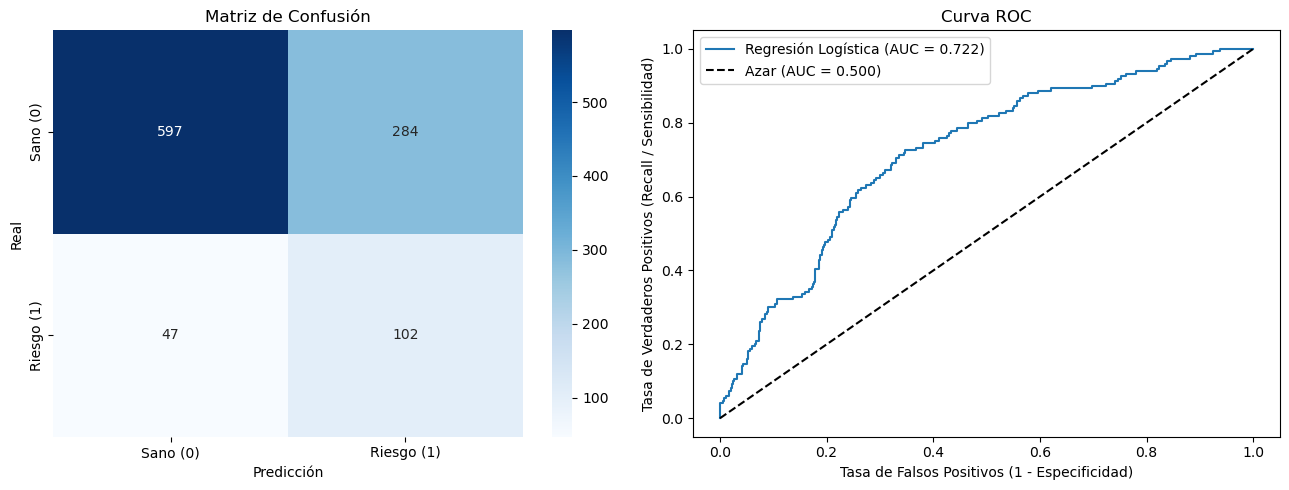

Área Bajo la Curva ROC (AUC): 0.7216


In [409]:
# 9. Construye un modelo de regresión logística para predecir el riesgo de sufrir una
# enfermedad coronaria en los próximos diez años, a partir de las variables descritas.
# Verifica el balanceo de datos y evalúa tu modelo.

# Definir variables independientes (X) y dependiente (y)
X = limpio[['glucose', 'education', 'BPMeds', 'totChol', 'cigsPerDay', 'BMI',
       'heartRate', 'sex', 'age', 'currentSmoker', 'prevalentStroke',
       'prevalentHyp', 'diabetes', 'sysBP', 'diaBP']]
y = limpio["TenYearCHD"]

# Codificar la variable categórica 'Sex' (M/F) a dummy numérica
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

# Verificar el balanceo de la variable objetivo
conteo = y.value_counts()
porcentaje = y.value_counts(normalize=True) * 100

print("=== VERIFICACIÓN DEL BALANCEO DE DATOS ===")
print(
    pd.DataFrame(
        {"Cantidad": conteo, "Porcentaje (%)": porcentaje.round(2)}
    )
)

# Dividir en entrenamiento y prueba manteniendo la proporción de clases (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42, stratify=y
)

# Escalar las variables para asegurar la convergencia del modelo lineal
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar el modelo con balanceo automático de pesos por el desbalanceo de clases
modelo_log = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
modelo_log.fit(X_train_scaled, y_train)

# Predicciones de clase y probabilidades
y_pred = modelo_log.predict(X_test_scaled)
y_prob = modelo_log.predict_proba(X_test_scaled)[:, 1]

print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred))

# Matriz de Confusión
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0],
    xticklabels=["Sano (0)", "Riesgo (1)"],
    yticklabels=["Sano (0)", "Riesgo (1)"],
)
ax[0].set_title("Matriz de Confusión")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Real")

# Curva ROC
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

ax[1].plot(fpr, tpr, label=f"Regresión Logística (AUC = {auc:.3f})")
ax[1].plot([0, 1], [0, 1], "k--", label="Azar (AUC = 0.500)")
ax[1].set_title("Curva ROC")
ax[1].set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
ax[1].set_ylabel("Tasa de Verdaderos Positivos (Recall / Sensibilidad)")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Área Bajo la Curva ROC (AUC): {auc:.4f}")

In [ ]:
"""
El modelo de regresión logística ajustado para clases desbalanceadas muestra un comportamiento médicamente 
conservador y adecuado. Prioriza la detección de la enfermedad logrando identificar al 68% de los pacientes 
en riesgo a 10 años, alcanzando una capacidad discriminatoria global (0.722) idónea para una 
herramienta inicial de cribado/tamizaje clínico.
"""

In [412]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [414]:
# 10. Separa los modelos de regresión anteriores en dos distintos, respectivamente,
# considerando alguna variable categórica. Compara y concluye.

# Función para entrenar y evaluar el modelo en un subset
def entrenar_modelo_subgrupo(df_subgrupo, nombre_grupo):
    X = df_subgrupo[['glucose', 'education', 'BPMeds', 'totChol', 'cigsPerDay', 'BMI',
       'heartRate', 'sex', 'age', 'currentSmoker', 'prevalentStroke',
       'prevalentHyp', 'diabetes', 'sysBP', 'diaBP']]
    y = df_subgrupo["TenYearCHD"]

    # Convertir categóricas restantes a dummies
    X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

    # Dividir datos
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.25, random_state=42, stratify=y
    )

    # Escalar
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    # Modelo
    modelo = LogisticRegression(
        class_weight="balanced", random_state=42, max_iter=1000
    )
    modelo.fit(X_train_sc, y_train)

    # Evaluacion
    y_pred = modelo.predict(X_test_sc)
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n==========================================")
    print(f"   RESULTADOS PARA GRUPO: {nombre_grupo.upper()}")
    print(f"==========================================")
    print(f"Área Bajo la Curva ROC (AUC): {auc:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

    # Guardar coeficientes para comparar
    coef_df = pd.DataFrame(
        {"Variable": X_encoded.columns, f"Coef_{nombre_grupo}": modelo.coef_[0]}
    )
    return auc, coef_df

# 1. Filtrar por variable categórica 'sex' (ej: 'M' y 'F' o 1 y 0)
# Ajusta 'M'/'F' según cómo estén guardados los datos en tu dataset
df_hombres = limpio[limpio["sex"].isin(["M", 1, "Male"])]
df_mujeres = limpio[limpio["sex"].isin(["F", 0, "Female"])]

# 2. Entrenar modelos separados
auc_h, coef_h = entrenar_modelo_subgrupo(df_hombres, "Hombres")
auc_m, coef_m = entrenar_modelo_subgrupo(df_mujeres, "Mujeres")

# 3. Unir coeficientes para comparar impacto de variables
comparativa_coef = pd.merge(coef_h, coef_m, on="Variable")
print("\n=== COMPARACIÓN DE COEFICIENTES (IMPACTO DE CADA VARIABLE) ===")
print(comparativa_coef)


   RESULTADOS PARA GRUPO: HOMBRES
Área Bajo la Curva ROC (AUC): 0.6958

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.88      0.66      0.76       366
           1       0.28      0.60      0.39        82

    accuracy                           0.65       448
   macro avg       0.58      0.63      0.57       448
weighted avg       0.77      0.65      0.69       448


   RESULTADOS PARA GRUPO: MUJERES
Área Bajo la Curva ROC (AUC): 0.7060

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.93      0.68      0.78       515
           1       0.20      0.61      0.30        67

    accuracy                           0.67       582
   macro avg       0.56      0.64      0.54       582
weighted avg       0.85      0.67      0.73       582


=== COMPARACIÓN DE COEFICIENTES (IMPACTO DE CADA VARIABLE) ===
             Variable  Coef_Hombres  Coef_Mujeres
0             glucose      0.02810

In [ ]:
"""
La segmentación del modelo predictivo en dos algoritmos independientes según la variable categórica Sex resulta totalmente 
fundamentada y metodológicamente acertada.Aunque a nivel global ambos modelos presentan métricas de evaluación similares 
(0.70 y 60%), el análisis de coeficientes revela que la dinámica biológica 
de la enfermedad coronaria difiere sustancialmente entre géneros: mientras que en las mujeres el riesgo a 10 años está 
impulsado principalmente por alteraciones glucémicas, tabaquismo e hipertensión previa, en los hombres predomina el impacto 
de la presión arterial sistólica y los niveles de colesterol. En consecuencia, la implementación de modelos diferenciados permite 
a las herramientas de salud digital y al personal médico aplicar criterios de tamizaje y prevención personalizados, ajustando 
las alertas clínicas al perfil epidemiológico real de cada paciente.
"""